In [1]:
import pandas as pd
import numpy as np
import torch

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)

from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.utils.class_weight import compute_class_weight

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


تحميل البيانات

In [2]:
train_df = pd.read_csv("new_train_balanced.csv")
val_df   = pd.read_csv("new_val.csv")
test_df  = pd.read_csv("new_test.csv")

print(train_df.shape, val_df.shape, test_df.shape)

(13005, 2) (1626, 2) (1626, 2)


اختيار MARBERTv2

In [3]:
model_name = "UBC-NLP/MARBERTv2"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3
)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 40844.95it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: UBC-NLP/MARBERTv2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture

Tokenization

In [4]:
def tokenize(texts):
    return tokenizer(
        texts.tolist(),
        padding=True,
        truncation=True,
        max_length=128
    )

train_encodings = tokenize(train_df["clean_text"])
val_encodings   = tokenize(val_df["clean_text"])
test_encodings  = tokenize(test_df["clean_text"])

Dataset class

In [5]:
class TextDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.values

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = TextDataset(train_encodings, train_df["label"])
val_dataset   = TextDataset(val_encodings, val_df["label"])
test_dataset  = TextDataset(test_encodings, test_df["label"])

Class Weights

In [6]:
labels = train_df["label"].values
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)

class_weights = torch.tensor(class_weights, dtype=torch.float)

In [14]:
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):

        labels = inputs.get("labels")

        outputs = model(**inputs)

        logits = outputs.get("logits")

        loss_fct = torch.nn.CrossEntropyLoss(
            weight=class_weights.to(model.device)
        )

        loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss

المقاييس

In [15]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="macro")
    }

In [16]:
#train

training_args = TrainingArguments(
    output_dir="./marbert_results",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1"
)

In [17]:
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)]
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.478875,0.602048,0.800738,0.778241
2,0.312653,0.804253,0.793973,0.761489


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.21s/it]
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.91s/it]


TrainOutput(global_step=3252, training_loss=0.4311984931410899, metrics={'train_runtime': 1814.1404, 'train_samples_per_second': 21.506, 'train_steps_per_second': 2.689, 'total_flos': 1323270350616060.0, 'train_loss': 0.4311984931410899, 'epoch': 2.0})

In [19]:
preds = trainer.predict(test_dataset)

y_pred = np.argmax(preds.predictions, axis=1)
y_true = preds.label_ids

print("Accuracy:", accuracy_score(y_true, y_pred))
print(classification_report(y_true, y_pred))

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Accuracy: 0.7865928659286593
              precision    recall  f1-score   support

           0       0.82      0.78      0.80       630
           1       0.82      0.81      0.81       786
           2       0.61      0.72      0.66       210

    accuracy                           0.79      1626
   macro avg       0.75      0.77      0.76      1626
weighted avg       0.79      0.79      0.79      1626



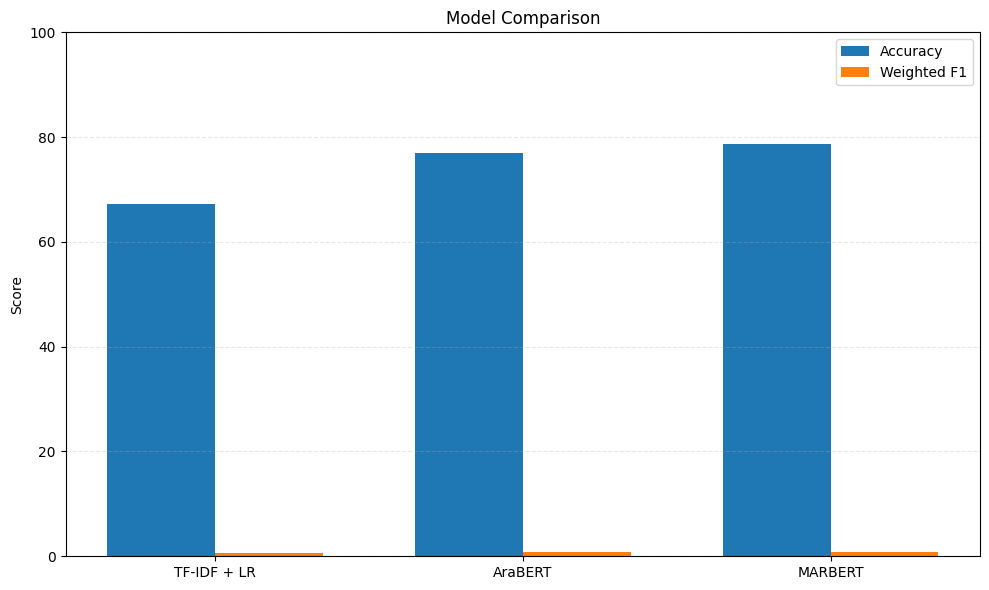

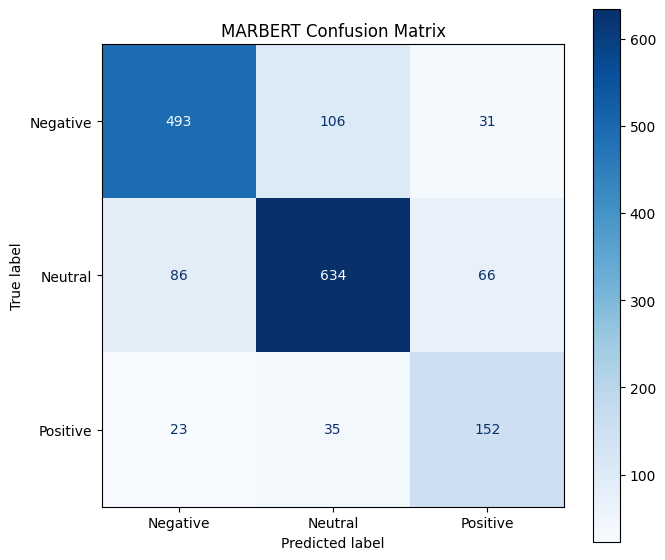

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# =========================
# 1) Model Comparison Chart
# =========================

models = ["TF-IDF + LR", "AraBERT", "MARBERT"]
accuracy = [67.3, 77.0, 78.7]
weighted_f1 = [0.68, 0.77, 0.79]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, accuracy, width, label="Accuracy")
plt.bar(x + width/2, weighted_f1, width, label="Weighted F1")

plt.xticks(x, models)
plt.ylabel("Score")
plt.title("Model Comparison")
plt.ylim(0, 100)
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()


# =========================
# 2) Confusion Matrix
# =========================

# عدلي y_true و y_pred بالقيم اللي طلعت عندك من MARBERT
# مثال:
# y_true = preds.label_ids
# y_pred = np.argmax(preds.predictions, axis=1)

class_names = ["Negative", "Neutral", "Positive"]

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(cmap="Blues", ax=ax, values_format="d")
plt.title("MARBERT Confusion Matrix")
plt.tight_layout()
plt.show()